In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
data = np.load("/scratch/vdeltatt/imbalance-gain-causality/tests_for_debarshi/ene_vs_tor/data/ene_tor.npy")
print(data.shape)

(1000, 500, 9)


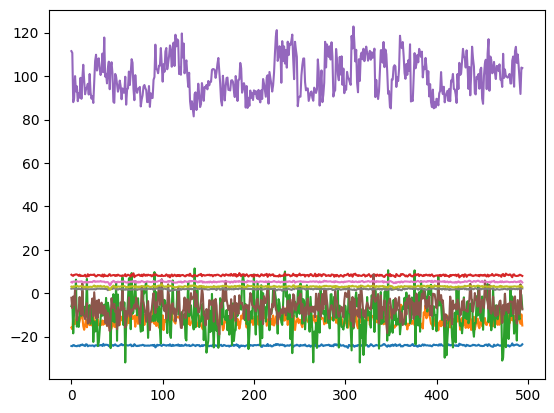

In [12]:
itraj = 0
for coord in range(9):
    plt.plot(data[itraj,5:,coord])
plt.show()

### Autocorrelation function

In [13]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

In [14]:
coords = np.arange(data.shape[2])

lag_max = 50
n_iid = 1000
acfs = np.zeros((len(coords), n_iid, lag_max))

for coord in tqdm(coords):
    for itraj in range(n_iid):
        acfs[coord, itraj] = autocorr2(data[0,5:,coord])[:lag_max]

100%|██████████| 9/9 [00:03<00:00,  2.33it/s]


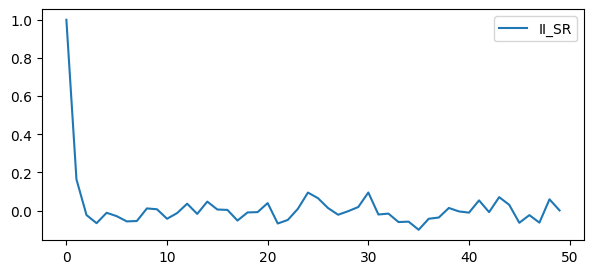

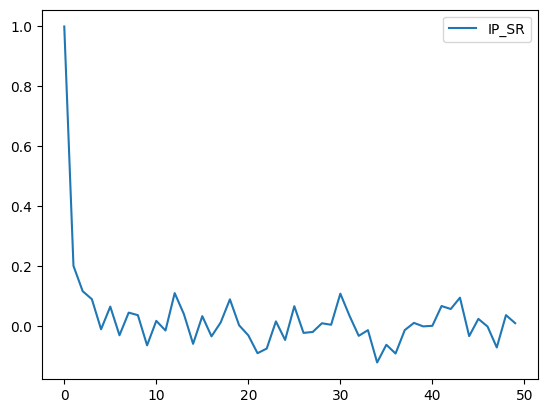

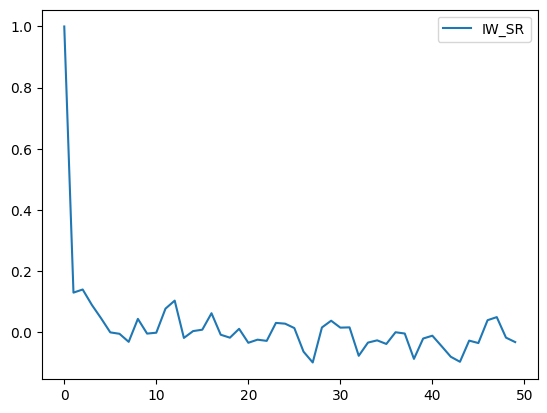

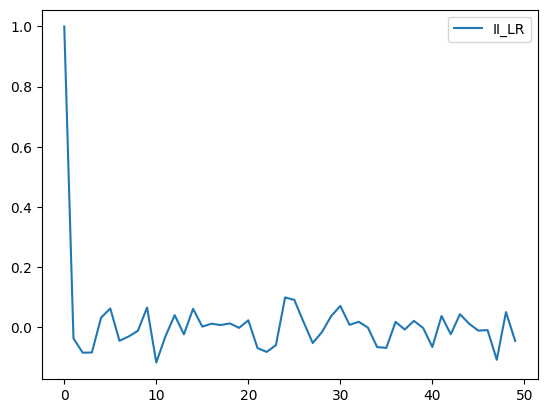

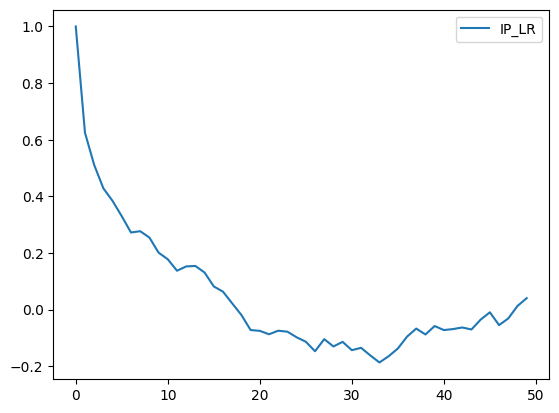

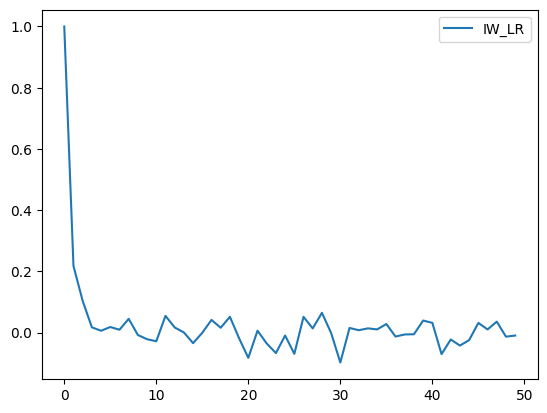

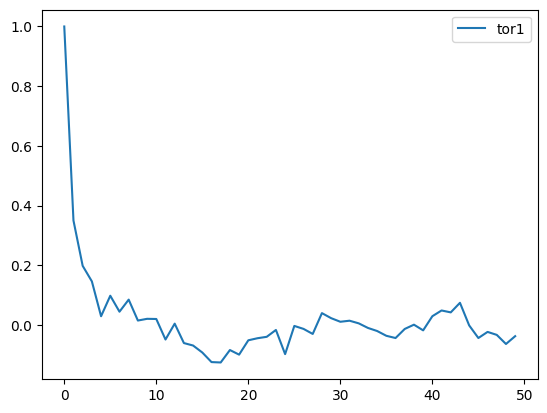

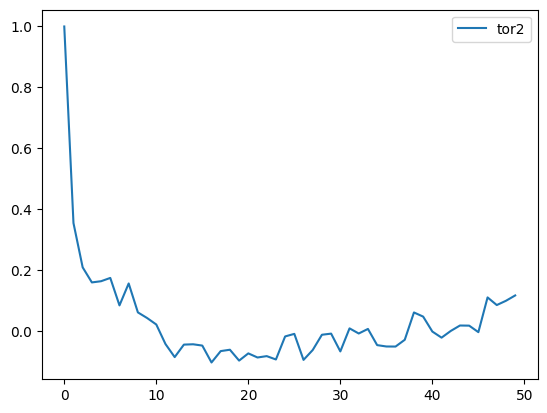

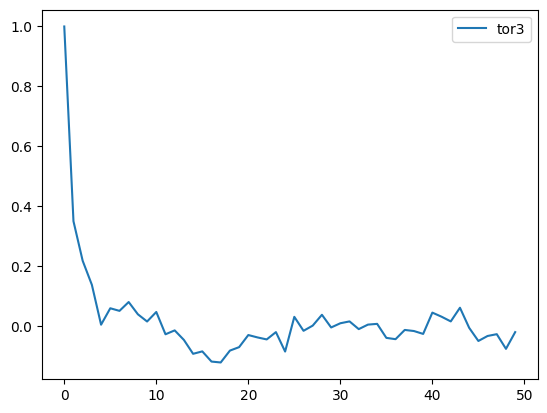

In [15]:
taus = np.arange(lag_max)
dict_labels = {0: "II_SR", 1: "IP_SR", 2: "IW_SR", 3: "II_LR", 4: "IP_LR",
            5: "IW_LR", 6: "tor1", 7: "tor2", 8: "tor3"}

plt.figure(figsize=(7,3))
for coord in coords:
    avg = acfs[coord].mean(axis=0)
    err = acfs[coord].std(axis=0) / np.sqrt(acfs[coord].shape[0])
    plt.plot(taus, avg, '-', label=dict_labels[coord])
    plt.fill_between(taus, avg - err, avg + err)
    plt.legend()
    plt.show()

### tor1 vs tor2, scatter plot

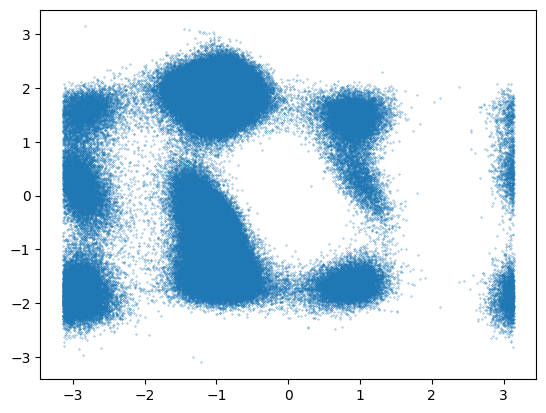

In [16]:
tor1 = np.ravel(data[:,:,-3])
tor1[tor1 > np.pi] = tor1[tor1 > np.pi] - 2*np.pi
tor2 = np.ravel(data[:,:,-2])
tor2[tor2 > np.pi] = tor2[tor2 > np.pi] - 2*np.pi
plt.plot(tor1, tor2, '.', markersize=0.5)
plt.show()

### tor1 vs tor3, scatter plot

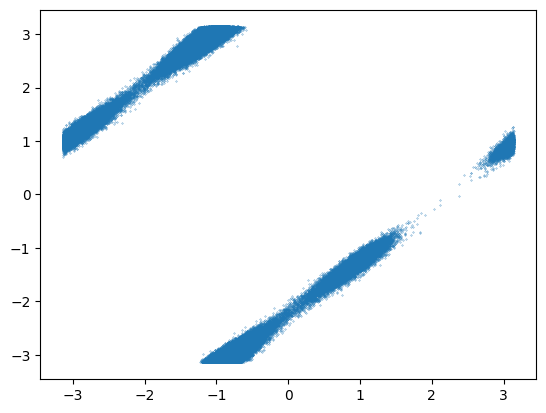

In [17]:
tor1 = np.ravel(data[:,:,-3])
tor1[tor1 > np.pi] = tor1[tor1 > np.pi] - 2*np.pi
tor3 = np.ravel(data[:,:,-1])
tor3[tor3 > np.pi] = tor3[tor3 > np.pi] - 2*np.pi
plt.plot(tor1, tor3, '.', markersize=0.5)
plt.show()